In [7]:
import numpy as np
import scipy.signal
import scipy.linalg
import cvxpy as cp
import matplotlib.pyplot as plt

In [8]:
m_B = 51.66 # mass of robot body (kg)
m_b = 2.44 # mass of ball (kg)
l = 0.69 # distance from ball COM to total COM (m)
I_b = 0.0174 # ball moment of inertia (kg-m^2)
r_b = 0.1058 # ball radius (m)
I_B = 12.59 # intertia of body wrt center of ball (kg-m^2)
mu_theta = 3.68 # theta viscous damping coefficient (N-m-s/rad)
mu_phi = 3.68 # phi viscous damping coefficient (N-m-s/rad)
dt = 0.1
g = 9.81
ki = 1
kp = 0.5

Gamma_1 = I_b + I_B + m_b * r_b**2 + m_B * r_b**2 + m_B * l**2
Gamma_2 = I_B + m_B * l**2

# Define the mass matrix M_*
M_star = np.array([
    [Gamma_1 + 2 * m_B * r_b * l, Gamma_2 + m_B * r_b * l],
    [Gamma_2 + m_B * r_b * l, Gamma_2]
])

# Compute the inverse of the mass matrix
M_star_inv = np.linalg.inv(M_star)

# Define the matrix to be multiplied by M_star_inv
matrix_to_multiply = np.array([
    [m_B * g * l, m_B * g * l, -mu_theta, 0, 0],
    [m_B * g * l - ki, m_B * g * l, -kp, -mu_phi, ki]
])

# Compute the resulting matrix
result_matrix = np.dot(M_star_inv, matrix_to_multiply)
result_matrix_2 = np.dot(M_star_inv, np.array([0, kp]))

# Construct the final A matrix
A = np.array([
    [0, 0, 1, 0, 0],
    [0, 0, 0, 1, 0],
    [result_matrix[0, 0], result_matrix[0, 1], result_matrix[0, 2], result_matrix[0, 3], result_matrix[0, 4]],
    [result_matrix[1, 0], result_matrix[1, 1], result_matrix[1, 2], result_matrix[1, 3], result_matrix[1, 4]],
    [0, 0, 0, 0, 0]
])

# Define the B matrix
B = np.array([
    [0],
    [0],
    [result_matrix_2[0]],
    [result_matrix_2[1]],
    [1]
])

sys_cont = scipy.signal.StateSpace(A, B, np.eye(5), np.zeros((5, 1)))
sys_disc = sys_cont.to_discrete(dt)
A_d = sys_disc.A
B_d = sys_disc.B

print('M_star eigenvalues (must both be > 0):', np.linalg.eigvals(M_star))
print('Continuous eig(A) (expect one positive = body falling):', np.round(np.linalg.eigvals(A), 3))
ctrb = np.hstack([np.linalg.matrix_power(A, i) @ B for i in range(5)])
print('Controllability rank (expect 5):', np.linalg.matrix_rank(ctrb))

M_star eigenvalues (must both be > 0): [82.42769967  0.1084949 ]
Continuous eig(A) (expect one positive = body falling): [-32.265   3.133  -2.686   0.144   0.   ]
Controllability rank (expect 5): 5


In [9]:
Q = np.diag([1, 1, 1, 1, 0])
R = np.array([[15]])

Initial_tilt = 0 # insert in degrees
IT_R = Initial_tilt * np.pi/180 # conversion to rad

Initial_velocity = 0 # insert in deg/s
IV_R = Initial_velocity * np.pi/180 #convert to rad/s

Initial_displacement = 1 # insert in m
ID_R = Initial_displacement / r_b # convert to rad

limit = 5 * np.pi/180 # angle limit
speed_limit = 0.04 / r_b

initial_state = np.array([ID_R, IT_R - ID_R, 0.0, IV_R, 0]) #Just ball displacement
state = initial_state
goal_state = np.zeros(5)

T = 800

us = cp.Variable([T,1]) 
xs = cp.Variable([T+1,5])

objective = 0
constraints = [xs[0] == initial_state]

for t in range(T):
  objective += (cp.quad_form(xs[t], Q) + cp.quad_form(us[t], R))
  constraints += [xs[t+1] == A_d @ xs[t] + B_d @ us[t]]
  constraints += [xs[t, 2] <= speed_limit, xs[t, 2] >= -speed_limit] # speed limit
  #constraints += [xs[t, 1] + xs[t,0] <= limit, xs[t, 1] + xs[t,0] >= -limit] # balancing

objective += cp.quad_form(xs[T] - goal_state, Q)
constraints += [xs[T] == goal_state]

problem = cp.Problem(cp.Minimize(objective), constraints)
problem.solve()
print('Solver status:', problem.status, '| optimal cost:', problem.value)


states = xs.value 
controls = us.value 

linear_position = states[:,0] * r_b

states = states * 180 / np.pi

test = np.sin(np.deg2rad(states[:,0] + states[:,1]))
test2 = states[:,1] + states [:,0]

Solver status: optimal | optimal cost: 32467.359561938007


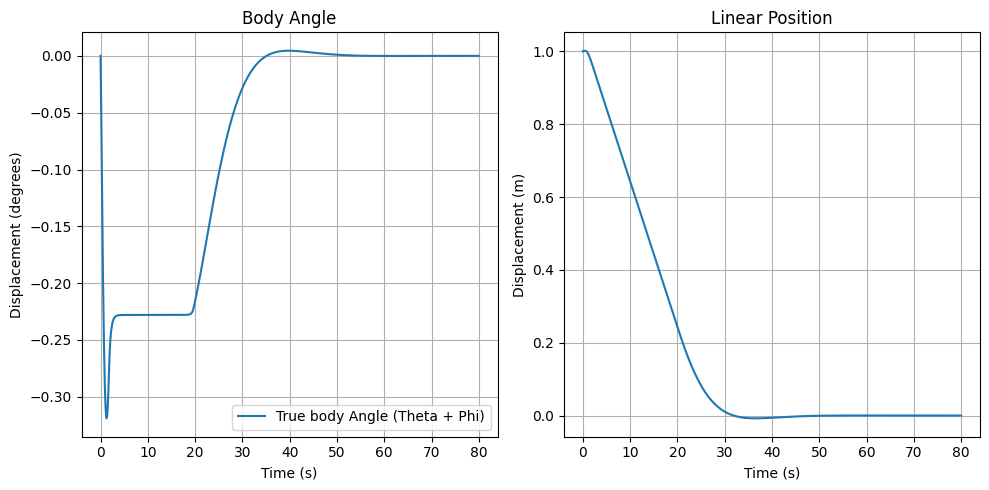

In [ ]:
Time = np.linspace(0, T*dt, T+1) 

# Plot the states
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
#plt.plot(Time, test, label = 'Sin(Theta + Phi)')
plt.plot(Time, test2, label = 'True body Angle (Theta + Phi)') 
#plt.plot(Time, states[:, 0], label='Ball Displacement')
#plt.plot(Time, states[:, 1], label='Body Angle')
#plt.plot(states[:, 2], label='Theta_D')
#plt.plot(states[:, 3], label='Phi_D')
plt.xlabel('Time (s)')
plt.ylabel('Displacement (degrees)')
plt.legend()
plt.title('Body Angle')
plt.grid()


# Plot the linear position
plt.subplot(1, 2, 2)
plt.plot(Time, linear_position)
plt.xlabel('Time (s)')
plt.ylabel('Displacement (m)')
plt.title('Linear Position')
plt.grid()

plt.tight_layout()
plt.show()